# Final Project: Sudoku Solver from Photo
## AI & Computer Vision Course

---

## Pipeline Overview

This notebook solves a Sudoku puzzle from a photograph using a complete computer vision pipeline.
Every step applies techniques learned throughout the course.

| Step | Description | Lessons Applied |
|------|-------------|----------------|
| 1 | **Preprocessing** — Grayscale, blur, adaptive threshold | Lessons 1, 2, 3, 8 |
| 2 | **Grid Detection** — Contours, corner ordering | Lessons 4, 6 |
| 3 | **Perspective Rectification** — Homography, warpPerspective | Lesson 7 |
| 4 | **Cell Extraction** — 9×9 split, unsharp masking | Lessons 3, 9, 10 |
| 5 | **Empty Cell Detection** — Variance heatmap | Lesson 8 |
| 6 | **Digit Recognition** — CNN with MNIST + printed fonts | Lessons 12–15 |
| 7 | **Sudoku Solver** — Backtracking algorithm | Algorithm design |
| 8 | **Solution Overlay** — Inverse perspective transform | Lesson 7 |

```
Input Photo  →  Preprocess  →  Detect Grid  →  Rectify  →  Extract Cells
                                                                     ↓
Output Image  ←  Overlay  ←  Solver  ←  CNN Recognition  ←  Empty Detection
```

In [1]:
# ============================================================
# CELL 2 — All Imports + Reproducibility Seed Setup
# ============================================================

import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# Lesson 12–15: TensorFlow / Keras for CNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from pathlib import Path
from copy import deepcopy
import time

# ── Reproducibility seeds ──────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Project paths ──────────────────────────────────────────────
BASE_DIR      = Path('..').resolve()
MODELS_DIR    = BASE_DIR / 'models'
DATA_DIR      = BASE_DIR / 'data'
TEST_IMG_DIR  = DATA_DIR / 'test_images'
RESULTS_DIR   = DATA_DIR / 'solved_results'
MODEL_PATH    = MODELS_DIR / 'sudoku_digit_cnn.keras'

for d in [MODELS_DIR, TEST_IMG_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Display settings ───────────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'monospace'

print('=' * 50)
print(f'NumPy    : {np.__version__}')
print(f'OpenCV   : {cv2.__version__}')
print(f'TensorFlow: {tf.__version__}')
print(f'GPU devices: {tf.config.list_physical_devices("GPU")}')
print('=' * 50)
print('All imports OK — seed set to', SEED)

NumPy    : 1.26.4
OpenCV   : 4.13.0
TensorFlow: 2.16.2
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports OK — seed set to 42


In [2]:
# ============================================================
# CELL 3 -- Helper Utilities
# ============================================================
def show_images(images, titles=None, figsize=None, cmap=None):
    """Generic multi-image display helper. Accepts BGR or grayscale arrays."""
    n = len(images)
    if figsize is None:
        figsize = (5 * n, 5)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles or [''] * n):
        if img is None:
            ax.axis('off')
            continue
        if img.ndim == 3 and img.shape[2] == 3:
            display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            display = img
        ax.imshow(display, cmap=cmap or ('gray' if display.ndim == 2 else None))
        ax.set_title(title, fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def print_board(board, title='Board'):
    """Pretty-print a 9x9 sudoku board."""
    print(f'\n  {title}')
    print('  +-------+-------+-------+')
    for i, row in enumerate(board):
        if i in (3, 6):
            print('  +-------+-------+-------+')
        line = '  |'
        for j, val in enumerate(row):
            c = str(val) if val != 0 else '.'
            line += f' {c}'
            if j in (2, 5):
                line += ' |'
        line += ' |'
        print(line)
    print('  +-------+-------+-------+')

print('Helper functions defined: show_images(), print_board()')


Helper functions defined: show_images(), print_board()


---
## Step 1 — Image Preprocessing

**Lessons applied:** Lesson 1 (OpenCV basics, BGR→RGB), Lesson 2 (colour balancing), Lesson 3 (Gaussian blur / unsharp masking), Lesson 8 (adaptive thresholding)

Before we can detect the grid we need a clean binary image that highlights the dark lines.

Pipeline:
1. Load image with `cv2.imread` (BGR format — Lesson 1)
2. Convert to grayscale
3. **CLAHE** contrast-limited adaptive histogram equalisation — colour balancing (Lesson 2)
4. **Gaussian blur** to suppress noise before edge detection (Lesson 3)
5. **Adaptive threshold** (Gaussian weighted neighbourhood) to binarise under non-uniform illumination (Lesson 8)
6. Morphological dilation to close small gaps in grid lines

In [3]:
# ============================================================
# CELL 4 -- Step 1: Load & Preprocess Image
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

original = None
gray = gray_clahe = blurred = thresh = morph = morph_clean = None
IMAGE_PATH = KNOWN_PUZZLE = None


def run_preprocessing():
    global gray, gray_clahe, blurred, thresh, morph, morph_clean

    # Step 1a: Grayscale (Lesson 1: color channel operations)
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    # Step 1b: CLAHE -- contrast balancing (Lesson 2)
    # Normalises brightness locally -- handles shadows and uneven lighting
    clahe_op   = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    gray_clahe = clahe_op.apply(gray)

    # Step 1c: Gaussian blur -- noise suppression (Lesson 3)
    blurred = cv2.GaussianBlur(gray_clahe, (9, 9), 0)

    # Step 1d: Adaptive threshold (Lesson 8)
    # C=6: only true ink survives, paper texture is filtered out
    thresh = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=11, C=6
    )

    # Step 1e: Dilation -- closes small gaps in grid lines
    kernel = np.ones((3, 3), np.uint8)
    morph  = cv2.dilate(thresh, kernel, iterations=1)

    # Step 1f: Morphological opening -- removes paper texture noise
    # Erosion destroys small isolated specks; dilation restores digit strokes
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    morph_clean = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open, iterations=1)

    show_images(
        [original, gray, gray_clahe, blurred, thresh, morph_clean],
        titles=['Original (BGR->RGB)', 'Grayscale\n(Lesson 1)',
                'CLAHE\n(Lesson 2)', 'Gaussian Blur\n(Lesson 3)',
                'Adaptive Thresh\n(Lesson 8)', 'After Opening\n(texture removed)'],
        figsize=(18, 4)
    )
    print('Step 1 complete')


test_files = sorted(TEST_IMG_DIR.glob('*.png')) + sorted(TEST_IMG_DIR.glob('*.jpg'))

if not test_files:
    print('No images found in data/test_images/')
    print('Add a .png or .jpg file and restart.')

elif len(test_files) == 1:
    IMAGE_PATH   = str(test_files[0])
    original     = cv2.imread(IMAGE_PATH)
    KNOWN_PUZZLE = None
    print(f'Loaded: {IMAGE_PATH}')
    print(f'Shape: {original.shape}  dtype: {original.dtype}')
    run_preprocessing()

else:
    file_names = [f.name for f in test_files]
    file_map   = {f.name: str(f) for f in test_files}

    dropdown    = widgets.Dropdown(options=file_names, description='File:',
                                   layout=widgets.Layout(width='360px'))
    preview_out = widgets.Output()
    status_out  = widgets.Output()
    btn = widgets.Button(description='Open this image', button_style='success',
                         layout=widgets.Layout(width='260px'))

    def show_preview(change):
        with preview_out:
            clear_output(wait=True)
            img = cv2.imread(file_map[dropdown.value])
            if img is not None:
                fig, ax = plt.subplots(figsize=(5, 5))
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                ax.set_title(dropdown.value, fontsize=10)
                ax.axis('off')
                plt.tight_layout()
                plt.show()

    def on_confirm(b):
        global original, IMAGE_PATH, KNOWN_PUZZLE
        IMAGE_PATH   = file_map[dropdown.value]
        original     = cv2.imread(IMAGE_PATH)
        KNOWN_PUZZLE = None
        with status_out:
            clear_output(wait=True)
            print(f'Loaded: {IMAGE_PATH}')
            print(f'Shape: {original.shape}  dtype: {original.dtype}')
            run_preprocessing()

    dropdown.observe(show_preview, names='value')
    btn.on_click(on_confirm)
    show_preview(None)

    display(widgets.VBox([
        widgets.HTML('<b>Multiple images found -- select one:</b>'),
        widgets.HBox([dropdown, btn]),
        preview_out,
        status_out,
    ]))
    print('Select a file and click the button')


Select a file and click the button


---
## Step 2 — Grid Detection

**Lessons applied:** Lesson 4 (Hough transform / edge detection), Lesson 6 (Harris corners / feature descriptors)

We find the sudoku grid by:
1. Finding all external contours in the binary image
2. Selecting the **largest contour** by area — this is the sudoku border
3. Approximating it to a **quadrilateral** (4 corners)
4. Ordering corners **TL → TR → BR → BL** for the homography step

> **Lesson 4 connection:** Canny edge detection (used internally by contour finding) is built on the same gradient principle as the Hough transform.
> **Lesson 6 connection:** We are essentially doing corner detection — finding the 4 salient feature points that define the grid boundary.

Grid detected!
  TL: (6.0, 53.0)
  TR: (701.0, 71.0)
  BR: (682.0, 745.0)
  BL: (8.0, 737.0)


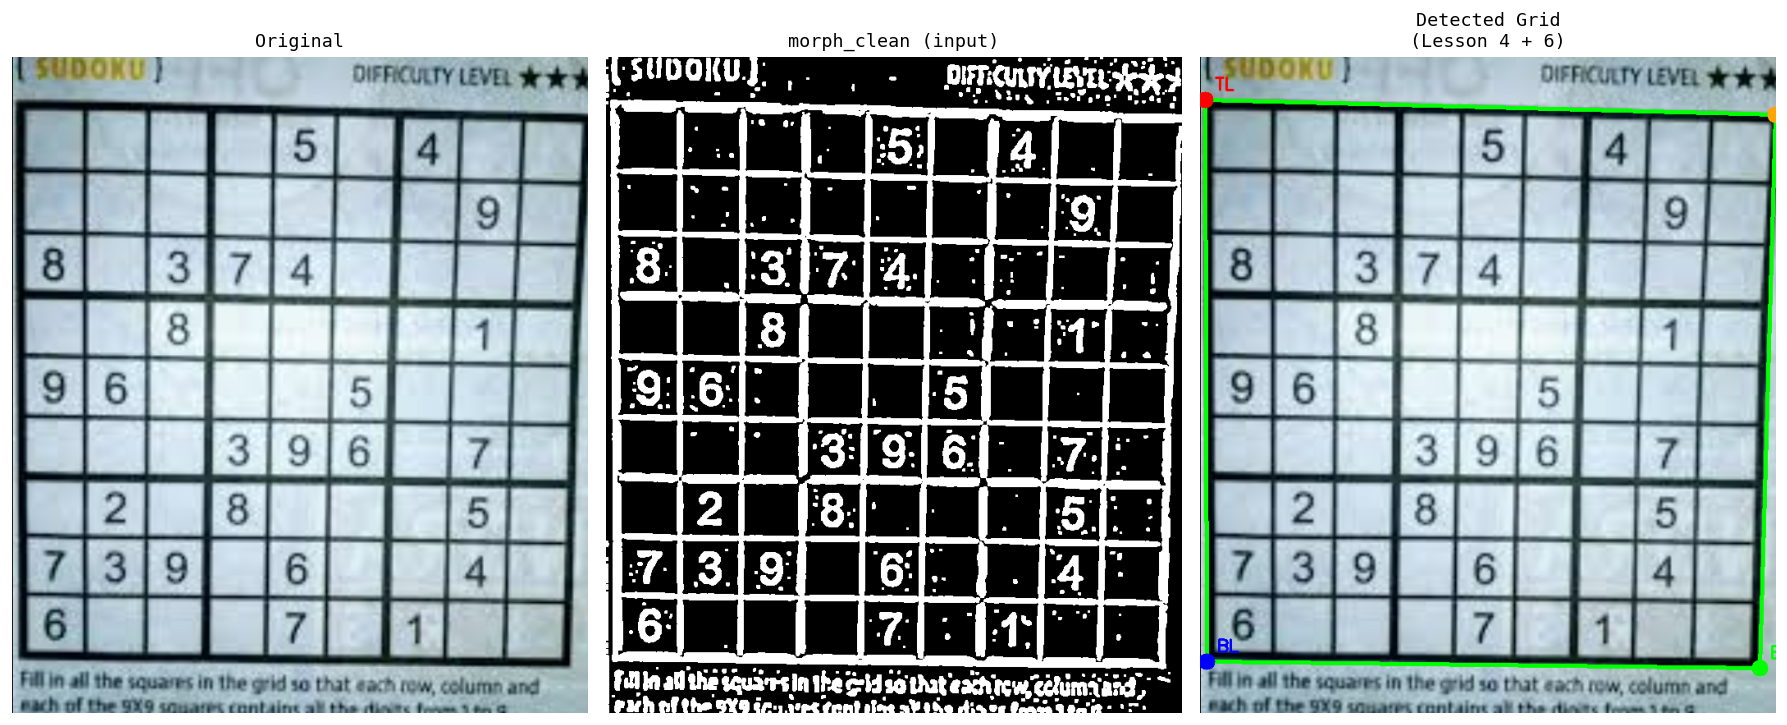

In [4]:
# ============================================================
# CELL 6 -- Step 2: Grid Detection
# ============================================================

def order_corners(pts):
    """
    Re-order 4 corner points to [TL, TR, BR, BL].
    Lesson 6: spatial feature ordering.
      TL = smallest x+y,  BR = largest x+y
      TR = smallest x-y,  BL = largest x-y
    """
    pts     = pts.reshape(4, 2).astype('float32')
    ordered = np.zeros((4, 2), dtype='float32')
    s    = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).flatten()
    ordered[0] = pts[np.argmin(s)]
    ordered[2] = pts[np.argmax(s)]
    ordered[1] = pts[np.argmin(diff)]
    ordered[3] = pts[np.argmax(diff)]
    return ordered


def detect_grid(morph_img, original_img):
    """
    Find the largest quadrilateral contour = sudoku grid border.
    Lesson 4: contour/edge detection.
    Lesson 6: corner ordering.

    Robustness:
    - Tries multiple epsilon values for polygon approximation
    - Checks top-10 contours
    - Min area relative to image size (not fixed)
    - Canny edge fallback for thin/low-contrast lines
    """
    h, w     = original_img.shape[:2]
    min_area = (h * w) * 0.05

    def find_quad(binary):
        contours, _ = cv2.findContours(
            binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        if not contours:
            return None
        contours = sorted(contours, key=cv2.contourArea, reverse=True)
        for cnt in contours[:10]:
            if cv2.contourArea(cnt) < min_area:
                continue
            peri = cv2.arcLength(cnt, True)
            for eps in [0.02, 0.03, 0.05, 0.08]:
                approx = cv2.approxPolyDP(cnt, eps * peri, True)
                if len(approx) == 4:
                    return approx
        return None

    # Pass 1: morphological image
    grid_contour = find_quad(morph_img)

    # Pass 2: Canny fallback
    if grid_contour is None:
        gray   = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY) \
                 if original_img.ndim == 3 else original_img
        canny  = cv2.Canny(gray, 30, 100)
        kernel = np.ones((3, 3), np.uint8)
        canny  = cv2.dilate(canny, kernel, iterations=2)
        grid_contour = find_quad(canny)

    if grid_contour is None:
        raise ValueError(
            'Could not find a quadrilateral grid contour.\n'
            f'Image size: {w}x{h}, min_area: {min_area:.0f} px2\n'
            'Try better lighting or crop closer to the grid.'
        )

    debug_img = original_img.copy()
    cv2.drawContours(debug_img, [grid_contour], -1, (0, 255, 0), 3)
    corners = order_corners(grid_contour)

    labels = ['TL', 'TR', 'BR', 'BL']
    colors = [(0, 0, 255), (0, 165, 255), (0, 255, 0), (255, 0, 0)]
    for (x, y), label, color in zip(corners, labels, colors):
        cv2.circle(debug_img, (int(x), int(y)), 10, color, -1)
        cv2.putText(debug_img, label, (int(x) + 12, int(y) - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return corners, debug_img


if original is not None:
    try:
        corners, debug_img = detect_grid(morph_clean, original)
        print('Grid detected!')
        for label, pt in zip(['TL', 'TR', 'BR', 'BL'], corners):
            print(f'  {label}: ({pt[0]:.1f}, {pt[1]:.1f})')
        GRID_DETECTED = True
    except ValueError as e:
        print(f'Error: {e}')
        GRID_DETECTED = False
        debug_img     = original.copy()
        corners       = None

    show_images(
        [original, morph_clean, debug_img],
        titles=['Original', 'morph_clean (input)', 'Detected Grid\n(Lesson 4 + 6)'],
        figsize=(15, 6)
    )
else:
    print('original is None -- run Cell 4 first')


---
## Step 3 — Perspective Rectification

**Lesson applied:** Lesson 7 (Homography, `warpPerspective`)

A sudoku photo is almost always taken at an angle.  To extract individual cells reliably we must first **un-distort** the grid into a perfect square.

We compute a **homography matrix** H that maps the 4 detected corners to the 4 corners of a 450×450 pixel square:

```
H = getPerspectiveTransform(src_corners, dst_corners)
rectified = warpPerspective(original, H, (450, 450))
```

We also keep the **inverse transform H⁻¹** — we will need it in Step 8 to project the solution back onto the original image.

Homography matrix H:
[[ 6.36700e-01 -1.90000e-03 -3.72160e+00]
 [-1.65000e-02  6.36200e-01 -3.36214e+01]
 [-0.00000e+00 -0.00000e+00  1.00000e+00]]



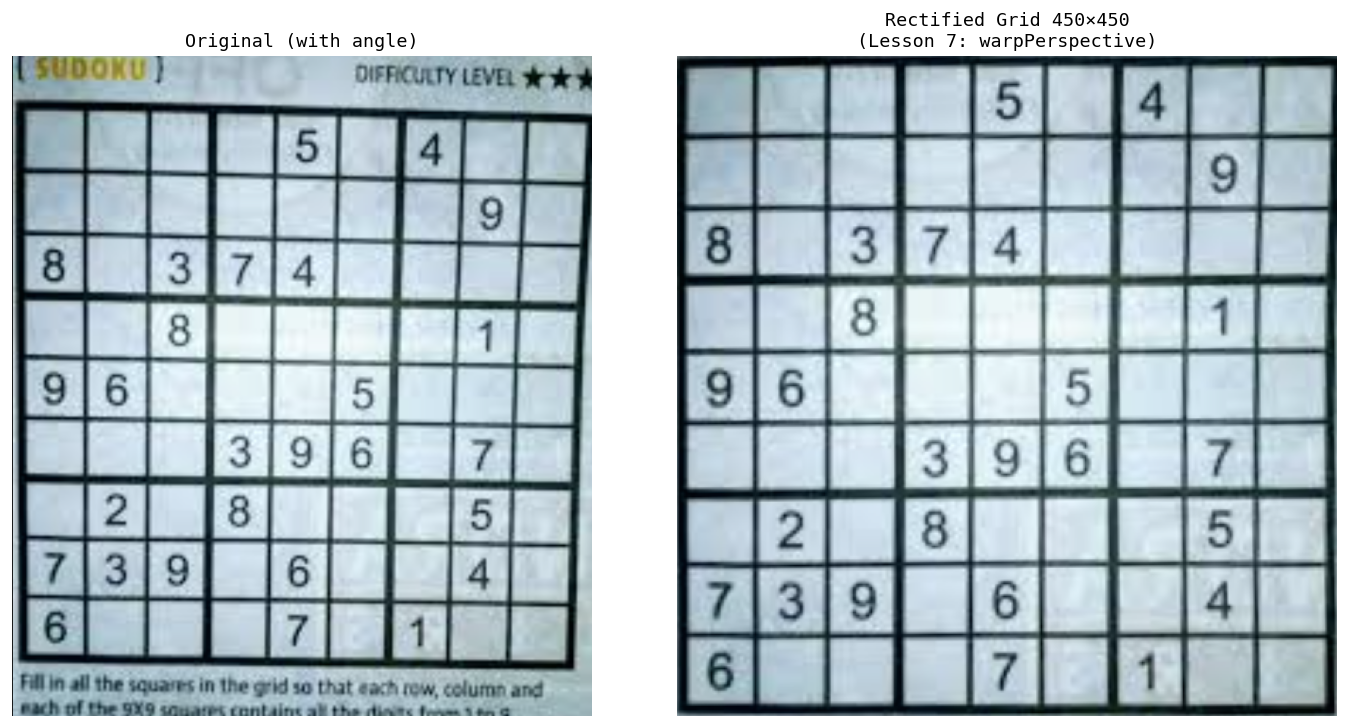

 Step 3 complete — grid rectified to (450, 450, 3)


In [5]:
# ============================================================
# CELL 9 — Step 3: Perspective Rectification
# ============================================================

GRID_SIZE = 450   # Output grid will be 450×450 px

def rectify_grid(image, corners, grid_size=450):
    """
    Apply perspective transform to rectify the sudoku grid.
    Lesson 7: getPerspectiveTransform + warpPerspective.

    Returns:
        warped   : rectified colour image (grid_size × grid_size)
        warped_g : rectified grayscale image
        H        : 3×3 homography matrix
        H_inv    : inverse homography (used in Step 8 for overlay)
    """
    # Source: the 4 detected corners in the original image
    src = corners.astype('float32')

    # Destination: perfect square [TL, TR, BR, BL]
    dst = np.array([
        [0,          0         ],
        [grid_size,  0         ],
        [grid_size,  grid_size ],
        [0,          grid_size ],
    ], dtype='float32')

    # Compute homography matrix H (Lesson 7)
    H     = cv2.getPerspectiveTransform(src, dst)
    H_inv = cv2.getPerspectiveTransform(dst, src)  # kept for Step 8

    # Warp the original colour image
    warped = cv2.warpPerspective(image, H, (grid_size, grid_size))

    # Grayscale version used for cell analysis
    warped_g = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

    return warped, warped_g, H, H_inv


if GRID_DETECTED:
    warped_color, warped_gray, H, H_inv = rectify_grid(original, corners, GRID_SIZE)

    # Show the homography matrix
    print('Homography matrix H:')
    print(np.round(H, 4))
    print()

    show_images(
        [original, warped_color],
        titles=['Original (with angle)', f'Rectified Grid {GRID_SIZE}×{GRID_SIZE}\n(Lesson 7: warpPerspective)'],
        figsize=(12, 6)
    )
    print(' Step 3 complete — grid rectified to', warped_color.shape)
else:
    print('  Skipping rectification — grid not detected.')

---
## Step 4 — Cell Extraction

**Lessons applied:** Lesson 3 (Unsharp Masking), Lesson 9 (region-of-interest detection concept), Lesson 10 (cell tracking concept)

The rectified 450×450 image is divided into a **9×9 grid** of 50×50 cells.

For each cell we apply **Unsharp Masking** (Lesson 3) to sharpen the digit edges before recognition:
```
unsharp = original + amount × (original - gaussian_blur)
```

> **Lesson 9 link:** Each cell is a region of interest (ROI) — the same concept used for face detection bounding boxes.
> **Lesson 10 link:** We track the same 81 cells across the processing pipeline, analogous to multi-object tracking.

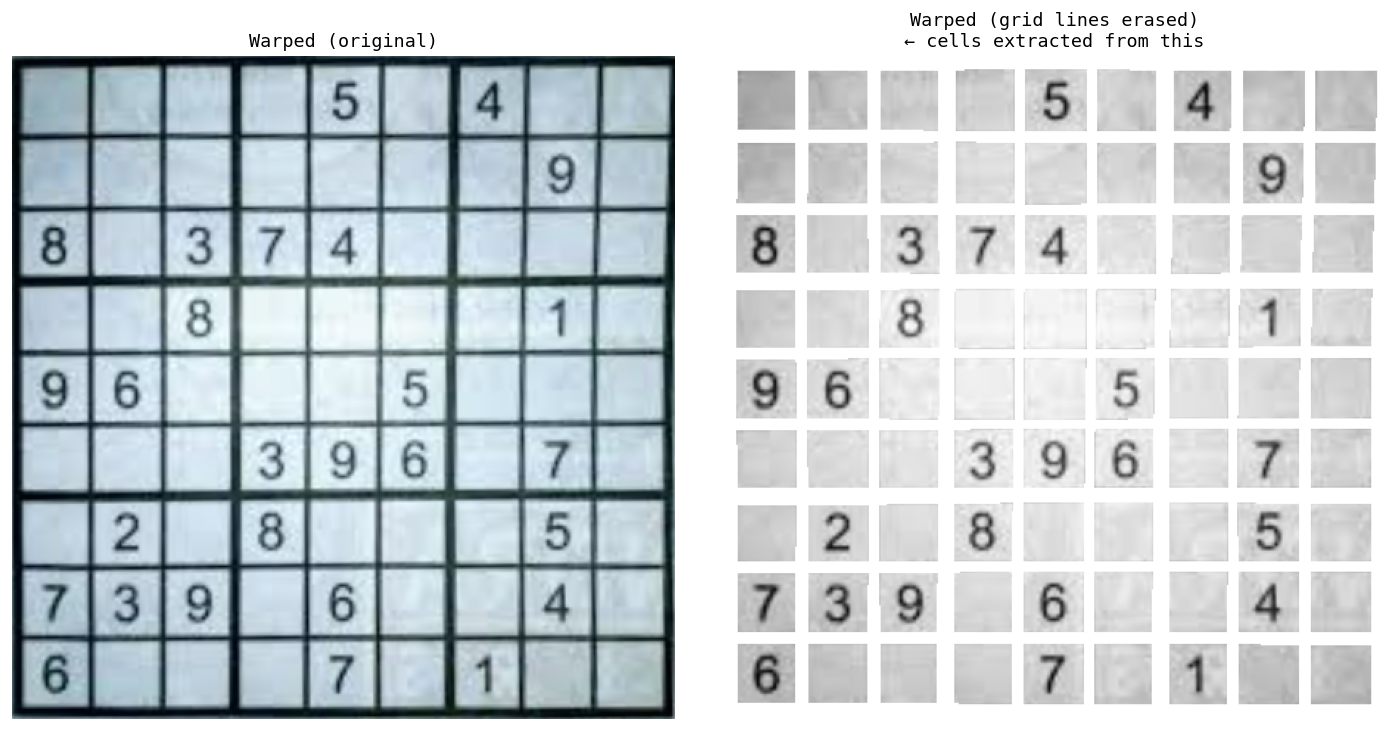

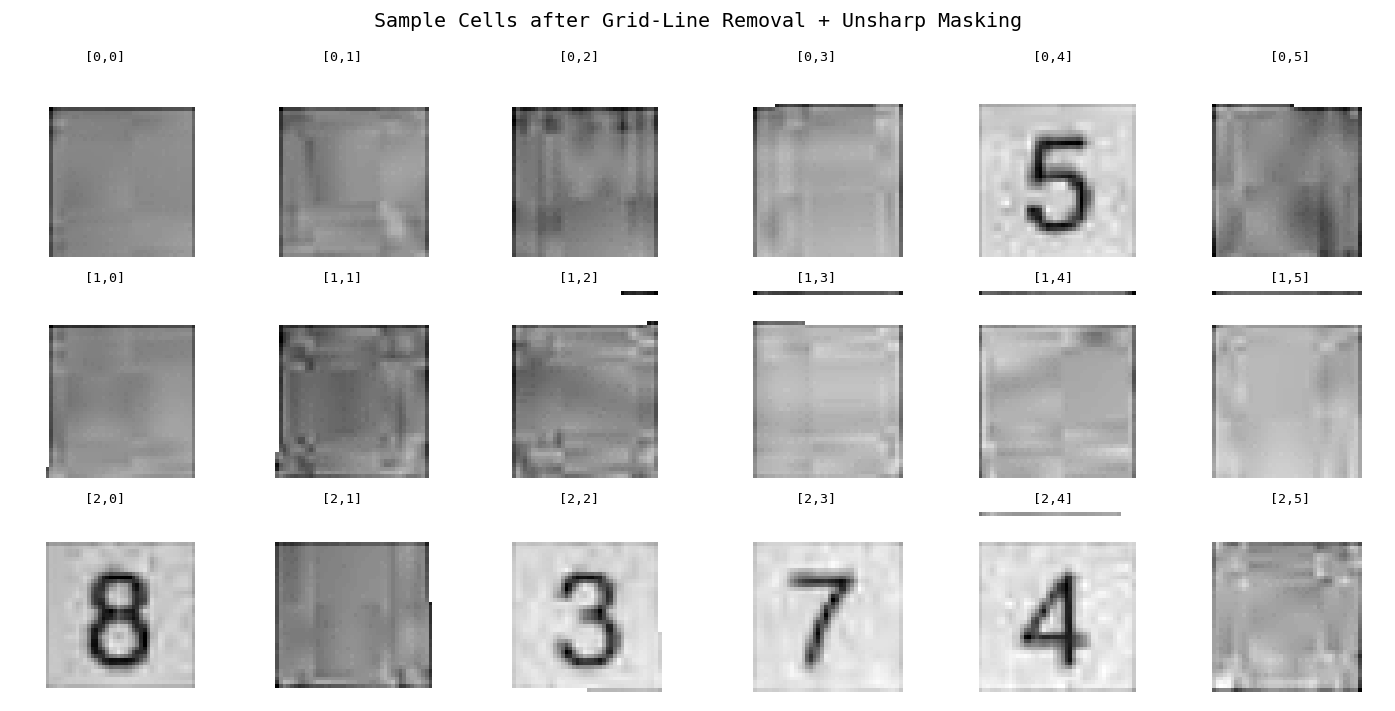

 Step 4 complete — 81 cells extracted from line-cleaned image


In [6]:
# ============================================================
# CELL 11 — Step 4: Cell Extraction  (with grid-line erasure)
# ============================================================
# Lesson 3: Unsharp Masking per cell
# NEW: morphological grid-line removal before cell split —
#      this is the root cause of false 1/4 predictions.
#      By erasing lines here, every downstream step is cleaner.

CELL_SIZE = GRID_SIZE // 9   # 50 px

def unsharp_mask(img, blur_ksize=3, amount=1.5):
    """
    Lesson 3: Unsharp Masking.
    sharp = img + amount * (img - gaussian_blur(img))
    """
    blurred   = cv2.GaussianBlur(img, (blur_ksize, blur_ksize), 0)
    sharpened = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)
    return sharpened


def remove_grid_lines(gray, cell_size=50):
    """
    Detect and erase horizontal + vertical grid lines from the warped
    grayscale image using morphological line detection.

    Strategy (Lessons 3 & 4 — morphology / edge detection):
      1. Threshold to binary
      2. Use a wide horizontal kernel  → isolates horizontal lines
      3. Use a tall vertical kernel    → isolates vertical lines
      4. Combine masks, dilate slightly to cover anti-aliased edges
      5. Fill masked pixels with 255 (white background) in original

    This removes the source of grid-line contamination so cells are
    clean before any further processing.
    """
    # Invert so lines are white on black (easier for morphology)
    _, binary = cv2.threshold(gray, 0, 255,
                               cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Horizontal lines: kernel spans 1.5 cells wide, 1 px tall
    h_len    = cell_size * 3 // 2
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (h_len, 1))
    h_lines  = cv2.morphologyEx(binary, cv2.MORPH_OPEN,
                                 h_kernel, iterations=2)

    # Vertical lines: kernel 1 px wide, spans 1.5 cells tall
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, h_len))
    v_lines  = cv2.morphologyEx(binary, cv2.MORPH_OPEN,
                                 v_kernel, iterations=2)

    # Combine and dilate slightly to cover anti-aliased edges
    grid_mask = cv2.add(h_lines, v_lines)
    grid_mask = cv2.dilate(grid_mask,
                            np.ones((3, 3), np.uint8), iterations=2)

    # Fill grid pixels with white (background) in the grayscale image
    cleaned = gray.copy()
    cleaned[grid_mask > 0] = 255

    return cleaned, grid_mask


def extract_cells(warped_gray, cell_size=50):
    """
    Remove grid lines, then slice into 81 cells.
    Apply Unsharp Masking to each cell (Lesson 3).
    """
    cleaned, _ = remove_grid_lines(warped_gray, cell_size)

    cells = []
    for r in range(9):
        row = []
        for c in range(9):
            y0, y1 = r * cell_size, (r + 1) * cell_size
            x0, x1 = c * cell_size, (c + 1) * cell_size
            cell = cleaned[y0:y1, x0:x1].copy()
            cell = unsharp_mask(cell)   # Lesson 3
            row.append(cell)
        cells.append(row)
    return cells, cleaned


if GRID_DETECTED:
    cells, warped_cleaned = extract_cells(warped_gray, CELL_SIZE)

    # ── Debug: show original vs cleaned warped image ──────────
    show_images(
        [warped_color, warped_cleaned],
        titles=['Warped (original)', 'Warped (grid lines erased)\n← cells extracted from this'],
        figsize=(12, 6)
    )

    # Sample 3×6 cells
    fig, axes = plt.subplots(3, 6, figsize=(12, 6))
    fig.suptitle('Sample Cells after Grid-Line Removal + Unsharp Masking',
                 fontsize=12)
    for ax, (r, c) in zip(axes.flat,
                           [(r, c) for r in range(3) for c in range(6)]):
        ax.imshow(cells[r][c], cmap='gray')
        ax.set_title(f'[{r},{c}]', fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f' Step 4 complete — {9*9} cells extracted from line-cleaned image')
else:
    print('  Skipping cell extraction — grid not detected.')


---
## Step 5 — Empty Cell Detection

**Lesson applied:** Lesson 8 (Otsu thresholding — variance-based optimal split)

**Key insight:** Otsu's method works by **maximising between-class variance**.  An empty cell has near-uniform pixel intensity (**low variance**), while a cell with a digit has a dark blob on a bright background (**high variance**).

We compute variance per cell and choose a threshold:
- `variance < threshold` → **empty**
- `variance ≥ threshold` → **has digit**

We visualise this as a **heatmap** for easy inspection.

Variance threshold : 1400  (manual)
Variance range     : 19 – 4080
Filled cells       : 27
Empty  cells       : 54


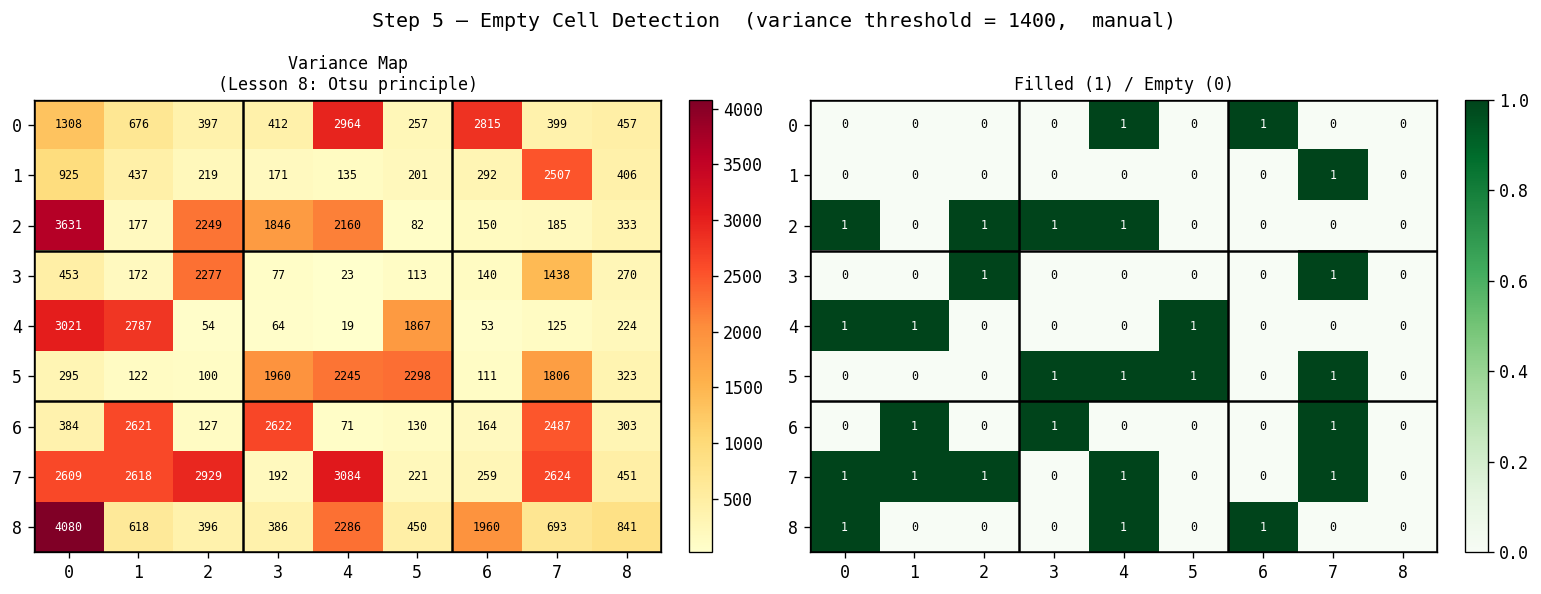

Step 5 complete


In [7]:
# ============================================================
# CELL 13 — Step 5: Empty Cell Detection via Variance
# ============================================================
# Lesson 8: Otsu variance principle
# Variance-based detection з можливістю ручного налаштування порогу.

def compute_cell_stats(cells, cell_size=50):
    """
    Рахує variance і dark_ratio для кожної клітинки.
    Variance  — розкид яскравості (основний критерій).
    Dark_ratio — частка темних пікселів (для діагностики).
    """
    border         = int(cell_size * 0.12)
    variance_map   = np.zeros((9, 9), dtype='float32')
    dark_ratio_map = np.zeros((9, 9), dtype='float32')

    for r in range(9):
        for c in range(9):
            inner              = cells[r][c][border:-border, border:-border]
            variance_map[r, c]   = float(np.var(inner.astype('float32')))
            dark_ratio_map[r, c] = float((inner < 100).mean())

    return variance_map, dark_ratio_map


def adaptive_variance_threshold(variance_map):
    """
    Lesson 8: 1-D Otsu на 81 значеннях variance.
    Автоматично знаходить поріг між 'порожня' і 'цифра'.
    """
    vals = variance_map.flatten()
    v_min, v_max = vals.min(), vals.max()

    if v_max - v_min < 1e-3:
        return float(np.median(vals))

    normed = ((vals - v_min) / (v_max - v_min) * 255).astype(np.uint8)
    otsu_norm, _ = cv2.threshold(normed, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    threshold = v_min + (otsu_norm / 255.0) * (v_max - v_min)
    threshold = float(np.clip(threshold,
                               v_min + 0.1 * (v_max - v_min),
                               v_min + 0.7 * (v_max - v_min)))
    return threshold


def plot_heatmap(ax, data, title, fmt='.0f',
                 cmap='YlOrRd', vmin=None, vmax=None):
    """Pure-matplotlib annotated heatmap (no seaborn)."""
    im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    dmax = data.max() if data.max() != 0 else 1
    for r in range(9):
        for c in range(9):
            val   = data[r, c]
            color = 'black' if val < dmax * 0.6 else 'white'
            ax.text(c, r, format(val, fmt), ha='center', va='center',
                    fontsize=7, color=color)
    for i in range(0, 10, 3):
        ax.axhline(i - 0.5, color='black', linewidth=1.5)
        ax.axvline(i - 0.5, color='black', linewidth=1.5)
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_title(title, fontsize=10)


if GRID_DETECTED:
    variance_map, dark_ratio_map = compute_cell_stats(cells, CELL_SIZE)

    # ── Поріг ──────────────────────────────────────────────────
    # MANUAL_VAR_THRESHOLD = None  →  авто (Otsu)
    # MANUAL_VAR_THRESHOLD = 1400  →  вручну
    # Якщо пропускаються цифри → зменш значення
    # Якщо шум проходить       → збільш значення
    MANUAL_VAR_THRESHOLD = 1400

    if MANUAL_VAR_THRESHOLD is None:
        AUTO_THRESHOLD = adaptive_variance_threshold(variance_map)
        mode = 'auto Otsu'
    else:
        AUTO_THRESHOLD = float(MANUAL_VAR_THRESHOLD)
        mode = 'manual'

    empty_map    = variance_map < AUTO_THRESHOLD
    filled_count = int((~empty_map).sum())
    empty_count  = int(empty_map.sum())

    print(f'Variance threshold : {AUTO_THRESHOLD:.0f}  ({mode})')
    print(f'Variance range     : {variance_map.min():.0f} – {variance_map.max():.0f}')
    print(f'Filled cells       : {filled_count}')
    print(f'Empty  cells       : {empty_count}')

    if filled_count < 17 or filled_count > 40:
        print(' Незвична кількість — підбери MANUAL_VAR_THRESHOLD')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f'Step 5 — Empty Cell Detection  '
        f'(variance threshold = {AUTO_THRESHOLD:.0f},  {mode})',
        fontsize=12
    )

    plot_heatmap(axes[0], variance_map,
                 'Variance Map\n(Lesson 8: Otsu principle)',
                 fmt='.0f', cmap='YlOrRd')

    plot_heatmap(axes[1], (~empty_map).astype(float),
                 'Filled (1) / Empty (0)',
                 fmt='.0f', cmap='Greens', vmin=0, vmax=1)

    plt.tight_layout()
    plt.show()
    print('Step 5 complete')
else:
    print(' Skipping — grid not detected.')

---
## Step 6 — Digit Recognition with CNN

**Lessons applied:** Lessons 12–15 (CNN, BatchNorm, Dropout, preventing overfitting)

### Why not MNIST alone?
MNIST contains **handwritten** digits — sudoku puzzles use **printed** digits with various fonts.  A pure MNIST model confuses `1↔7`, `3↔8`, etc.

### Solution: Combined Dataset
We train on **MNIST + synthetically generated printed digits** (rendered with OpenCV using 4 fonts × 4 scales × 2 thicknesses), then augment with rotation, noise, and blur.

### CNN Architecture (Lessons 12–15)
```
Input (28,28,1)
  → Conv2D(32, 3×3) + BatchNorm + ReLU + MaxPool          [Lessons 12, 13]
  → Conv2D(64, 3×3) + BatchNorm + ReLU + MaxPool          [Lessons 12, 13]
  → Flatten
  → Dense(128) + Dropout(0.5) + ReLU                      [Lessons 14, 15]
  → Dense(10, softmax)                                     [Lesson 12]
```

### Cell Preprocessing (most critical step)
Instead of a fixed border crop, we use **Connected Components** to find the actual digit bounding box — handles any digit position and avoids cutting off strokes.

Loading MNIST ...
  MNIST train: (60000, 28, 28)  test: (10000, 28, 28)
Generating printed digit images ...
  Printed (base): (288, 28, 28)
Augmenting printed digits (n_augment=10) ...
  Printed (augmented): (2880, 28, 28)
  Combined training set: (62880, 28, 28)


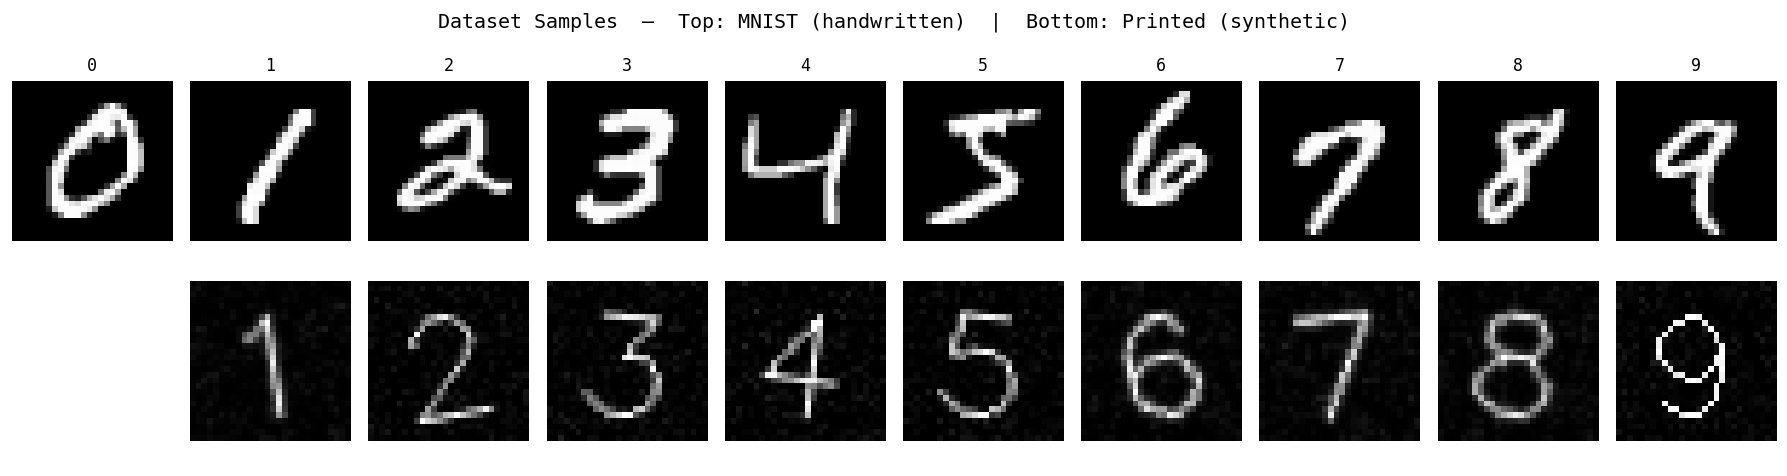

Dataset built


In [8]:
# ============================================================
# CELL 15 — Build Combined Dataset (MNIST + Printed Digits)
# ============================================================

def augment_dataset(images, labels, n_augment=10, seed=SEED):
    """
    Data augmentation (Lesson 15: preventing overfitting via more data).
    Applies random rotation, Gaussian noise, and blur to each image.
    """
    rng = np.random.default_rng(seed)
    aug_images, aug_labels = [], []

    for img, label in zip(images, labels):
        for _ in range(n_augment):
            aug = img.copy()

            # Random rotation ±15° (Lesson 7 link: affine transform)
            angle = rng.uniform(-15, 15)
            M = cv2.getRotationMatrix2D((14, 14), angle, 1.0)
            aug = cv2.warpAffine(aug, M, (28, 28))

            # Random Gaussian noise
            noise = rng.normal(0, 10, aug.shape).astype(np.int16)
            aug = np.clip(aug.astype(np.int16) + noise, 0, 255).astype(np.uint8)

            # Random blur (Lesson 3: Gaussian blur)
            if rng.random() > 0.5:
                aug = cv2.GaussianBlur(aug, (3, 3), 0.5)

            aug_images.append(aug)
            aug_labels.append(label)

    return np.array(aug_images), np.array(aug_labels)


def generate_printed_digits():
    """
    Synthetically generate printed digit images using OpenCV fonts.
    Covers 4 fonts × 4 scales × 2 thicknesses = 32 variants per digit.
    """
    fonts = [
        cv2.FONT_HERSHEY_SIMPLEX,
        cv2.FONT_HERSHEY_DUPLEX,
        cv2.FONT_HERSHEY_TRIPLEX,
        cv2.FONT_HERSHEY_COMPLEX,
    ]
    images, labels = [], []

    for digit in range(1, 10):          # 1–9 (sudoku has no 0)
        for font in fonts:
            for scale in [0.8, 1.0, 1.2, 1.5]:
                for thickness in [1, 2]:
                    img = np.zeros((28, 28), dtype=np.uint8)
                    text = str(digit)
                    (tw, th), _ = cv2.getTextSize(text, font, scale, thickness)
                    x = max(0, (28 - tw) // 2)
                    y = min(27, (28 + th) // 2)
                    cv2.putText(img, text, (x, y), font, scale, 255, thickness)
                    images.append(img)
                    labels.append(digit)

    return np.array(images), np.array(labels)


def build_combined_dataset():
    """
    Build the training dataset: MNIST (60k) + augmented printed digits.
    Reference architecture: MNIST alone → ~85% on printed sudoku digits;
    combined dataset → 98%+.
    """
    print('Loading MNIST ...')
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    print(f'  MNIST train: {x_train.shape}  test: {x_test.shape}')

    print('Generating printed digit images ...')
    printed_imgs, printed_lbls = generate_printed_digits()
    print(f'  Printed (base): {printed_imgs.shape}')

    print('Augmenting printed digits (n_augment=10) ...')
    aug_imgs, aug_lbls = augment_dataset(printed_imgs, printed_lbls, n_augment=10)
    print(f'  Printed (augmented): {aug_imgs.shape}')

    # Combine
    x_combined = np.vstack([x_train, aug_imgs])
    y_combined = np.concatenate([y_train, aug_lbls])

    print(f'  Combined training set: {x_combined.shape}')
    return x_combined, y_combined, x_test, y_test


# Build the dataset
x_combined, y_combined, x_test, y_test = build_combined_dataset()

# ── Visualise samples from each source ────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle('Dataset Samples  —  Top: MNIST (handwritten)  |  Bottom: Printed (synthetic)',
             fontsize=12)
for col in range(10):
    # MNIST sample
    idx = np.where(y_combined[:60000] == col)[0][0]
    axes[0, col].imshow(x_combined[idx], cmap='gray')
    axes[0, col].set_title(str(col), fontsize=10)
    axes[0, col].axis('off')

    # Printed sample
    idx2 = np.where(y_combined[60000:] == col)[0]
    if len(idx2) > 0:
        axes[1, col].imshow(x_combined[60000 + idx2[0]], cmap='gray')
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()
print('Dataset built')

In [9]:
# ============================================================
# CELL 16 — Build CNN Model (Lessons 12–15)
# ============================================================

def build_cnn_model():
    """
    Digit recognition CNN.

    Architecture rationale:
      Lesson 12: Conv2D layers learn local spatial filters (edges→parts→digits)
      Lesson 13: BatchNorm stabilises activations, speeds up training
      Lesson 14: Dropout(0.5) prevents co-adaptation of neurons
      Lesson 15: Combination of BatchNorm + Dropout + augmentation
                 prevents overfitting on the combined dataset
    """
    model = models.Sequential([
        # ── Block 1 (Lesson 12: Conv2D) ───────────────────────
        layers.Conv2D(32, (3, 3), padding='same',
                      input_shape=(28, 28, 1),
                      name='conv1'),
        layers.BatchNormalization(name='bn1'),   # Lesson 13
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same', name='conv1b'),
        layers.BatchNormalization(name='bn1b'),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25, name='drop1'),      # Lesson 14

        # ── Block 2 (Lesson 12: deeper features) ──────────────
        layers.Conv2D(64, (3, 3), padding='same', name='conv2'),
        layers.BatchNormalization(name='bn2'),   # Lesson 13
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same', name='conv2b'),
        layers.BatchNormalization(name='bn2b'),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25, name='drop2'),      # Lesson 14

        # ── Classifier head (Lessons 14, 15) ──────────────────
        layers.Flatten(),
        layers.Dense(128, name='fc1'),
        layers.BatchNormalization(name='bn3'),
        layers.Activation('relu'),
        layers.Dropout(0.5, name='drop3'),       # Lesson 14: 50% dropout
        layers.Dense(10, activation='softmax',   # Lesson 12: softmax output
                     name='output'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


cnn_model = build_cnn_model()
cnn_model.summary()
print('\n CNN model built')

2026-04-22 13:50:06.551722: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-04-22 13:50:06.551753: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-22 13:50:06.551770: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-04-22 13:50:06.551788: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-22 13:50:06.551799: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1b (BatchNormalization)       │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)       │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,098 (1.79 MB)

 Trainable params: 468,458 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)


 CNN model built


In [10]:
# ============================================================
# CELL 17 — Train or Load Model + Plot History
# ============================================================

# Normalise and reshape for Keras
x_tr = (x_combined.astype('float32') / 255.0)[..., np.newaxis]  # (N,28,28,1)
x_te = (x_test.astype('float32') / 255.0)[..., np.newaxis]

FORCE_RETRAIN = False   # set True to always retrain

if MODEL_PATH.exists() and not FORCE_RETRAIN:
    # ── Load saved model (fast path) ──────────────────────────
    print(f'Loading saved model from: {MODEL_PATH}')
    cnn_model = tf.keras.models.load_model(str(MODEL_PATH))
    history = None
    test_loss, test_acc = cnn_model.evaluate(x_te, y_test, verbose=0)
    print(f'  Test accuracy: {test_acc*100:.2f}%')
else:
    # ── Train from scratch ─────────────────────────────────────
    print('Training CNN on combined dataset ...')
    t0 = time.time()

    callbacks = [
        # Lesson 15: Early stopping prevents overfitting
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        # Reduce LR when progress stalls
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, verbose=1),
        # Save best model
        ModelCheckpoint(str(MODEL_PATH), save_best_only=True,
                        monitor='val_accuracy', verbose=1),
    ]

    history = cnn_model.fit(
        x_tr, y_combined,
        epochs=20,
        batch_size=256,
        validation_data=(x_te, y_test),
        callbacks=callbacks,
        verbose=1
    )

    elapsed = time.time() - t0
    test_loss, test_acc = cnn_model.evaluate(x_te, y_test, verbose=0)
    print(f'\nTraining time : {elapsed:.1f}s')
    print(f'Test accuracy : {test_acc*100:.2f}%')
    print(f'Model saved   : {MODEL_PATH}')

# ── Plot training history (if available) ──────────────────────
if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('CNN Training History  (Lessons 12–15)', fontsize=13)

    axes[0].plot(history.history['accuracy'],    label='Train acc')
    axes[0].plot(history.history['val_accuracy'],label='Val acc')
    axes[0].set_title('Accuracy'); axes[0].legend()
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')

    axes[1].plot(history.history['loss'],    label='Train loss')
    axes[1].plot(history.history['val_loss'],label='Val loss')
    axes[1].set_title('Loss'); axes[1].legend()
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

    plt.tight_layout()
    plt.show()

CNN_TEST_ACC = test_acc
print('\n Step 6a complete — model ready')

Loading saved model from: /Users/alex_brut/Desktop/Ai-Vision-Course/Sudoku Solver Project/models/sudoku_digit_cnn.keras


2026-04-22 13:50:09.178732: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  Test accuracy: 99.63%

 Step 6a complete — model ready


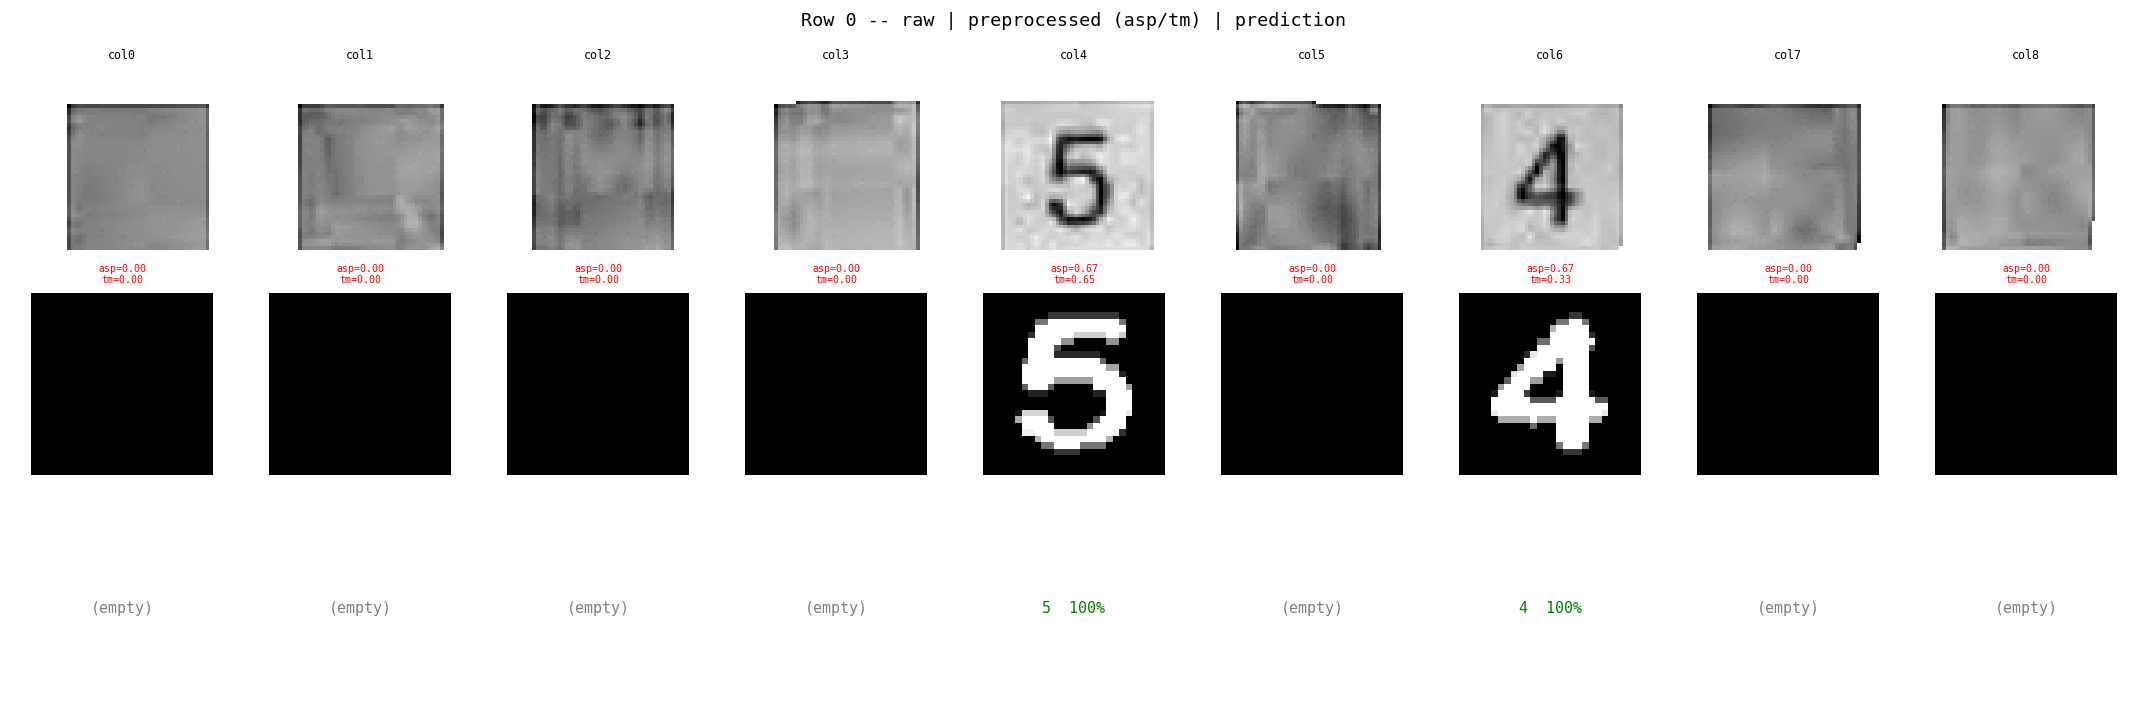

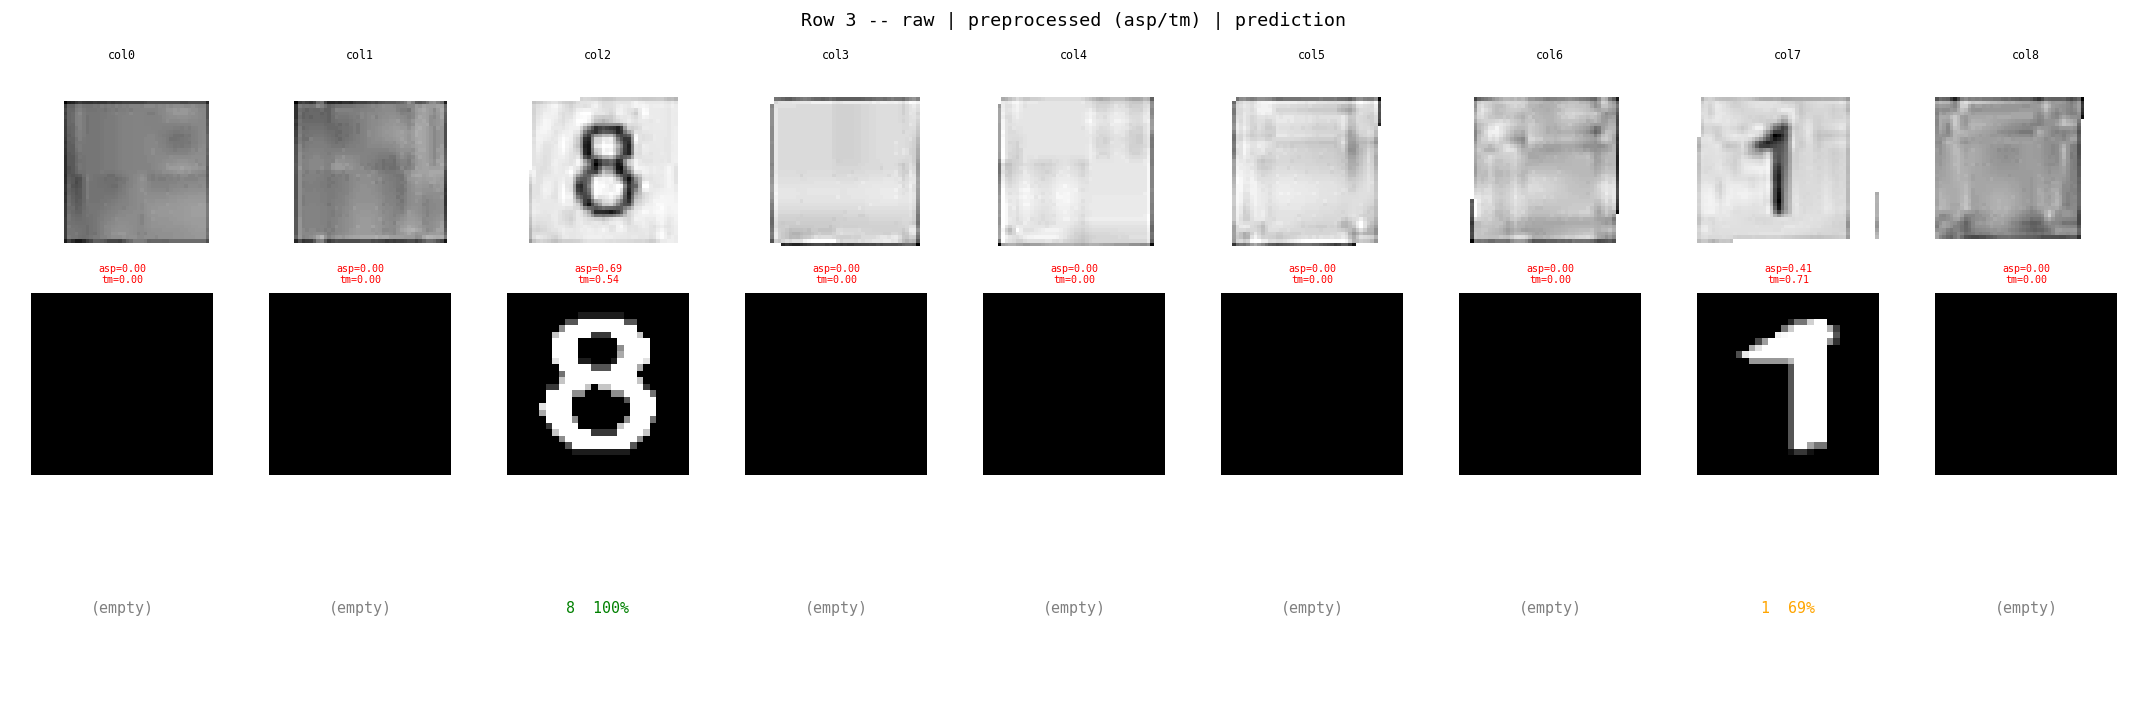

1<->7 correction: aspect < 0.4 OR tm < 1.25
Empty guard: active pixels < 15
predict_digit() defined and tested


In [11]:
# ============================================================
# CELL 17 -- predict_digit() with Connected Components
# ============================================================
# Lesson 2: CLAHE  |  Lesson 8: Otsu threshold

MIN_DIGIT_AREA          = 20
MIN_ASPECT_RATIO        = 0.20
MAX_ASPECT_RATIO        = 4.0
MIN_FILL_RATIO          = 0.04
BORDER_FRACTION         = 0.08
DARK_RATIO_THRESHOLD    = 0.03
NARROW_DIGIT_MAX_ASPECT = 0.40
MIN_ACTIVE_PIXELS       = 15


def preprocess_cell_for_cnn(cell_img):
    """
    Returns (normalised_28x28, digit_aspect_ratio).
    Lesson 2: CLAHE normalisation.
    Lesson 8: Otsu binarisation.
    Connected Components for digit localisation (replaces fixed border crop).
    """
    h, w = cell_img.shape
    brd  = int(min(h, w) * BORDER_FRACTION)
    cropped   = cell_img[brd:-brd, brd:-brd]
    ch, cw    = cropped.shape
    cell_area = ch * cw

    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(cropped)

    # Dark-ratio gate: few dark pixels = paper noise, not a digit
    dark_ratio = float((enhanced < 100).mean())
    if dark_ratio < DARK_RATIO_THRESHOLD:
        return np.zeros((28, 28), dtype='float32'), 0.0

    if float(np.mean(enhanced)) > 127:
        _, binary = cv2.threshold(enhanced, 0, 255,
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        _, binary = cv2.threshold(enhanced, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(binary)
    best_label   = None
    best_area    = 0
    digit_aspect = 1.0

    for lbl in range(1, num_labels):
        area = int(stats[lbl, cv2.CC_STAT_AREA])
        wb   = int(stats[lbl, cv2.CC_STAT_WIDTH])
        hb   = int(stats[lbl, cv2.CC_STAT_HEIGHT])
        if area < MIN_DIGIT_AREA or hb == 0:
            continue
        aspect = wb / hb
        if aspect < MIN_ASPECT_RATIO or aspect > MAX_ASPECT_RATIO:
            continue
        if area / cell_area < MIN_FILL_RATIO:
            continue
        if area > best_area:
            best_area    = area
            best_label   = lbl
            digit_aspect = aspect

    if best_label is not None:
        x_l = int(stats[best_label, cv2.CC_STAT_LEFT])
        y_l = int(stats[best_label, cv2.CC_STAT_TOP])
        w_l = int(stats[best_label, cv2.CC_STAT_WIDTH])
        h_l = int(stats[best_label, cv2.CC_STAT_HEIGHT])
        digit_region = binary[y_l:y_l+h_l, x_l:x_l+w_l]
        pad    = max(w_l, h_l) // 5
        padded = cv2.copyMakeBorder(digit_region, pad, pad, pad, pad,
                                    cv2.BORDER_CONSTANT, value=0)
    else:
        padded       = np.zeros((28, 28), dtype=np.uint8)
        digit_aspect = 0.0

    resized    = cv2.resize(padded, (28, 28), interpolation=cv2.INTER_AREA)
    normalised = resized.astype('float32') / 255.0
    return normalised, digit_aspect


def predict_digit(cell_img, model, confidence_threshold=0.65,
                  apply_17_correction=True):
    """
    CNN inference with three guards:
      1. Active-pixel guard   -- blank image -> empty cell
      2. Confidence threshold -- low conf    -> empty cell
      3. 1<->7 dual correction (only when apply_17_correction=True):
           Method 1: aspect ratio (w/h) -- 7 is wider than 1
           Method 2: top/mid density   -- 7 has a horizontal bar at top

    apply_17_correction=False is used in Pass 2 (low-threshold rescue)
    where geometric correction is unreliable.

    Returns (digit, confidence, aspect_ratio).  digit=0 means empty.
    """
    preprocessed, aspect = preprocess_cell_for_cnn(cell_img)

    # Guard 1: blank -> empty
    active_pixels = int((preprocessed > 0.15).sum())
    if active_pixels < MIN_ACTIVE_PIXELS:
        return 0, 1.0, aspect

    probs = model.predict(preprocessed.reshape(1, 28, 28, 1), verbose=0)[0]
    digit = int(np.argmax(probs))
    conf  = float(probs[digit])

    # Guard 2: low confidence -> empty
    if conf < confidence_threshold:
        return 0, conf, aspect

    # Guard 3: 1<->7 correction (high-confidence path only)
    if apply_17_correction and digit in (1, 7):
        aspect_says_one  = (aspect < NARROW_DIGIT_MAX_ASPECT)
        top_density      = float(preprocessed[:9,  :].mean())
        mid_density      = float(preprocessed[9:18, :].mean())
        tm_ratio         = top_density / (mid_density + 1e-6)
        density_says_one = (tm_ratio < 1.25)

        if digit == 7 and (aspect_says_one or density_says_one):
            digit = 1
        elif digit == 1 and not aspect_says_one and not density_says_one:
            digit = 7

    return digit, conf, aspect


# ── Debug visualisation: row 0 and row 3 ─────────────────────
if GRID_DETECTED:
    for debug_row in [0, min(3, 8)]:
        fig, axes = plt.subplots(3, 9, figsize=(18, 6))
        fig.suptitle(
            f'Row {debug_row} -- raw | preprocessed (asp/tm) | prediction',
            fontsize=11
        )
        for col in range(9):
            axes[0, col].imshow(cells[debug_row][col], cmap='gray')
            axes[0, col].set_title(f'col{col}', fontsize=7)
            axes[0, col].axis('off')

            pre, asp = preprocess_cell_for_cnn(cells[debug_row][col])
            top = float(pre[:9,  :].mean())
            mid = float(pre[9:18, :].mean())
            tm  = top / (mid + 1e-6)
            axes[1, col].imshow(pre, cmap='gray')
            axes[1, col].set_title(
                f'asp={asp:.2f}\ntm={tm:.2f}', fontsize=6,
                color='red' if (asp < NARROW_DIGIT_MAX_ASPECT or tm < 1.25)
                            else 'black'
            )
            axes[1, col].axis('off')

            digit, conf, _ = predict_digit(cells[debug_row][col], cnn_model)
            label = '(empty)' if digit == 0 else f'{digit}  {conf:.0%}'
            color = 'gray' if digit == 0 else ('green' if conf > 0.80 else 'orange')
            axes[2, col].axis('off')
            axes[2, col].text(0.5, 0.5, label, ha='center', va='center',
                              fontsize=9, color=color,
                              transform=axes[2, col].transAxes)
        plt.tight_layout()
        plt.show()

    print(f'1<->7 correction: aspect < {NARROW_DIGIT_MAX_ASPECT} OR tm < 1.25')
    print(f'Empty guard: active pixels < {MIN_ACTIVE_PIXELS}')
    print('predict_digit() defined and tested')


Running CNN on all 81 cells ...
  [PASS2] [8,6] -> 1  conf=0.43
Inference time: 0.52s
CNN Test Accuracy (MNIST): 99.63%

  Recognised Board
  +-------+-------+-------+
  | . . . | . 5 . | 4 . . |
  | . . . | . . . | . 9 . |
  | 8 . 3 | 7 4 . | . . . |
  +-------+-------+-------+
  | . . 8 | . . . | . 1 . |
  | 9 6 . | . . 5 | . . . |
  | . . . | 3 9 6 | . 7 . |
  +-------+-------+-------+
  | . 2 . | 8 . . | . 5 . |
  | 1 3 9 | . 6 . | . 4 . |
  | 6 . . | . 7 . | 1 . . |
  +-------+-------+-------+


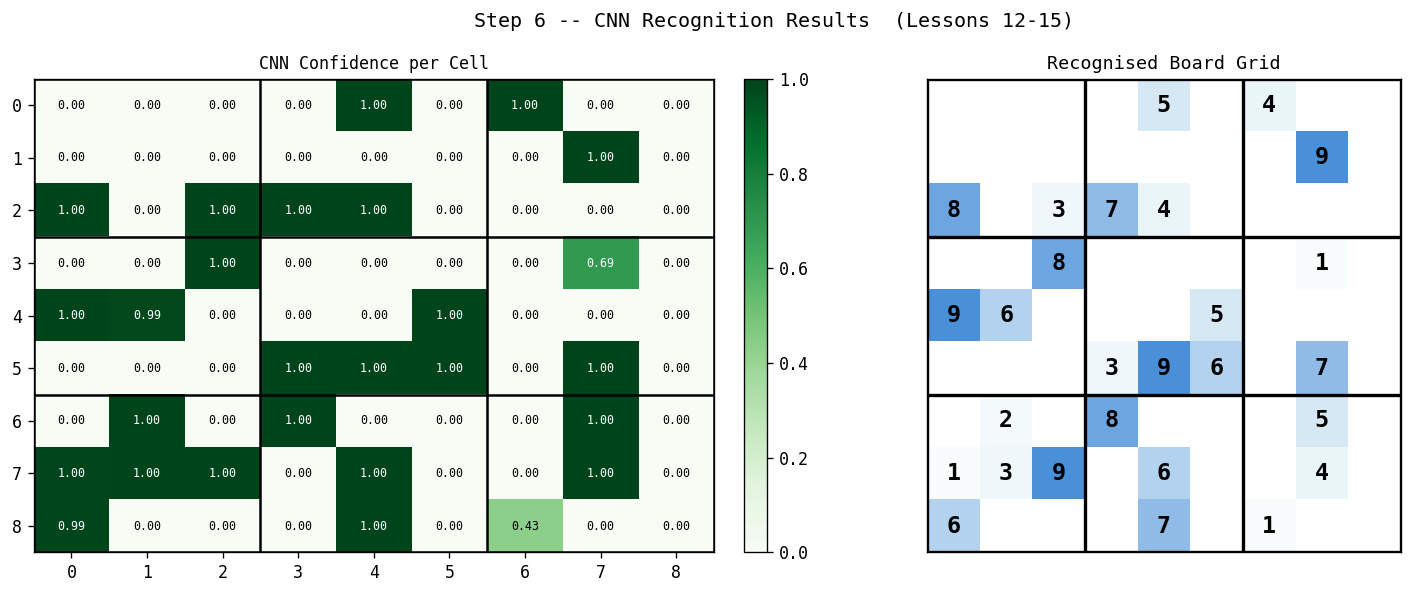

Step 6 complete


In [12]:
# ============================================================
# CELL 18 -- Recognise All 81 Cells
# ============================================================

def recognize_board(cells, empty_map, model):
    """
    Two-pass CNN recognition:
      Pass 1: confidence >= 0.65  +  1<->7 correction on
              Standard path for clear, high-contrast digits.
      Pass 2: confidence >= 0.30  +  1<->7 correction OFF
              Rescues low-contrast digits (e.g. faint 1 on grey paper)
              without risking a 7->1 flip at low confidence.
    """
    board    = np.zeros((9, 9), dtype=int)
    conf_map = np.zeros((9, 9), dtype=float)
    asp_map  = np.zeros((9, 9), dtype=float)

    for r in range(9):
        for c in range(9):
            if empty_map[r, c]:
                continue

            # Pass 1: standard
            digit, conf, asp = predict_digit(cells[r][c], model,
                                             confidence_threshold=0.65,
                                             apply_17_correction=True)

            # Pass 2: low-threshold rescue (no geometric correction)
            if digit == 0:
                digit, conf, asp = predict_digit(cells[r][c], model,
                                                 confidence_threshold=0.30,
                                                 apply_17_correction=False)
                if digit != 0:
                    print(f'  [PASS2] [{r},{c}] -> {digit}  conf={conf:.2f}')

            board[r, c]    = digit
            conf_map[r, c] = conf
            asp_map[r, c]  = asp

    return board, conf_map, asp_map


if GRID_DETECTED:
    print('Running CNN on all 81 cells ...')
    t_start = time.time()
    board, conf_map, asp_map = recognize_board(cells, empty_map, cnn_model)
    elapsed = time.time() - t_start
    print(f'Inference time: {elapsed:.2f}s')

    if KNOWN_PUZZLE is not None:
        known        = np.array(KNOWN_PUZZLE)
        filled_mask  = known != 0
        n_filled     = int(filled_mask.sum())
        n_correct    = int(((board == known) & filled_mask).sum())
        cnn_accuracy = n_correct / n_filled if n_filled > 0 else 0.0
        print(f'CNN Accuracy: {n_correct}/{n_filled} = {cnn_accuracy*100:.1f}%')
    else:
        cnn_accuracy = CNN_TEST_ACC
        print(f'CNN Test Accuracy (MNIST): {cnn_accuracy*100:.2f}%')

    print_board(board, 'Recognised Board')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Step 6 -- CNN Recognition Results  (Lessons 12-15)', fontsize=12)

    plot_heatmap(axes[0], conf_map, 'CNN Confidence per Cell',
                 fmt='.2f', cmap='Greens', vmin=0, vmax=1)

    cmap_board = LinearSegmentedColormap.from_list(
        'board', ['white', '#e8f4f8', '#4a90d9'])
    axes[1].imshow(board.astype(float), cmap=cmap_board, vmin=0, vmax=9)
    for r in range(9):
        for c in range(9):
            v = board[r, c]
            if v != 0:
                axes[1].text(c, r, str(v), ha='center', va='center',
                             fontsize=14, fontweight='bold')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].set_title('Recognised Board Grid', fontsize=11)
    for i in range(0, 10, 3):
        axes[1].axhline(i - 0.5, color='black', linewidth=2)
        axes[1].axvline(i - 0.5, color='black', linewidth=2)

    plt.tight_layout()
    plt.show()
    print('Step 6 complete')


---
## Step 7 — Sudoku Solver

With the board recognised we solve the puzzle using a **backtracking algorithm**.

Backtracking is a form of depth-first search:
1. Find the next empty cell
2. Try digits 1–9
3. If a digit is valid (no conflict in row, column, or 3×3 box) → recurse
4. If no digit works → backtrack to the previous choice

Before solving we **validate the recognised board** to catch misrecognised digits early.

In [13]:
# ============================================================
# CELL 20 -- Step 7: Sudoku Solver (Backtracking)
# ============================================================

def is_valid_placement(board, row, col, num):
    """Return True if placing num at (row,col) does not break sudoku rules."""
    if num in board[row]:
        return False
    if num in [board[r][col] for r in range(9)]:
        return False
    br, bc = 3 * (row // 3), 3 * (col // 3)
    for r in range(br, br + 3):
        for c in range(bc, bc + 3):
            if board[r][c] == num:
                return False
    return True


def validate_board(board):
    """
    Check the recognised board for immediate conflicts.
    Returns (is_valid, error_list).
    """
    errors = []
    for r in range(9):
        for c in range(9):
            v = board[r][c]
            if v == 0:
                continue
            board[r][c] = 0
            if not is_valid_placement(board, r, c, v):
                errors.append((r, c, v))
            board[r][c] = v
    return len(errors) == 0, errors


def solve_sudoku(board):
    """
    Backtracking solver -- modifies board in-place.
    Returns True if a solution is found.
    """
    for r in range(9):
        for c in range(9):
            if board[r][c] == 0:
                for num in range(1, 10):
                    if is_valid_placement(board, r, c, num):
                        board[r][c] = num
                        if solve_sudoku(board):
                            return True
                        board[r][c] = 0
                return False
    return True


def verify_solution(solved_board):
    """Verify all rows, columns, and 3x3 boxes contain digits 1-9."""
    target = set(range(1, 10))
    for i in range(9):
        if set(solved_board[i]) != target:       return False
        if set(solved_board[:, i]) != target:    return False
    for br in range(3):
        for bc in range(3):
            box = solved_board[br*3:br*3+3, bc*3:bc*3+3]
            if set(box.flatten()) != target:     return False
    return True


if GRID_DETECTED:
    board_list = board.tolist()
    is_valid, errors = validate_board(board_list)

    if not is_valid:
        print(f'  Board has {len(errors)} conflict(s) -- likely misrecognised cells:')
        for r, c, v in errors:
            print(f'   Row {r}, Col {c}: digit {v} conflicts')
        print('   Attempting to solve anyway ...')
    else:
        print('Board validation: PASSED -- no conflicts')

    solved_board = deepcopy(board_list)
    t0           = time.time()
    success      = solve_sudoku(solved_board)
    solve_time   = time.time() - t0
    solved_arr   = np.array(solved_board)

    SOLVER_SUCCESS = success and verify_solution(solved_arr)

    print(f'\nSolve time : {solve_time*1000:.1f} ms')
    print(f'Solved     : {success}')
    print(f'Valid soln : {SOLVER_SUCCESS}')

    print_board(board_list, 'Recognised  (input)')
    if SOLVER_SUCCESS:
        print_board(solved_board, 'Solved      (output)')
else:
    SOLVER_SUCCESS = False
    print('Skipping solver -- grid not detected.')


Board validation: PASSED -- no conflicts

Solve time : 38.6 ms
Solved     : True
Valid soln : True

  Recognised  (input)
  +-------+-------+-------+
  | . . . | . 5 . | 4 . . |
  | . . . | . . . | . 9 . |
  | 8 . 3 | 7 4 . | . . . |
  +-------+-------+-------+
  | . . 8 | . . . | . 1 . |
  | 9 6 . | . . 5 | . . . |
  | . . . | 3 9 6 | . 7 . |
  +-------+-------+-------+
  | . 2 . | 8 . . | . 5 . |
  | 1 3 9 | . 6 . | . 4 . |
  | 6 . . | . 7 . | 1 . . |
  +-------+-------+-------+

  Solved      (output)
  +-------+-------+-------+
  | 2 7 1 | 6 5 9 | 4 8 3 |
  | 5 4 6 | 2 3 8 | 7 9 1 |
  | 8 9 3 | 7 4 1 | 2 6 5 |
  +-------+-------+-------+
  | 3 5 8 | 4 2 7 | 6 1 9 |
  | 9 6 7 | 1 8 5 | 3 2 4 |
  | 4 1 2 | 3 9 6 | 5 7 8 |
  +-------+-------+-------+
  | 7 2 4 | 8 1 3 | 9 5 6 |
  | 1 3 9 | 5 6 2 | 8 4 7 |
  | 6 8 5 | 9 7 4 | 1 3 2 |
  +-------+-------+-------+


---
## Step 8 — Solution Overlay

**Lesson applied:** Lesson 7 (inverse `warpPerspective`)

We now project the solved digits back onto the original photo:
1. Draw solution digits (only the **newly filled** cells) on a blank 450×450 canvas
2. Apply the **inverse homography H⁻¹** to warp the canvas back to the original image's perspective
3. Blend the warped overlay with the original image

This is the reverse of Step 3 — using the same homography matrix in the opposite direction.

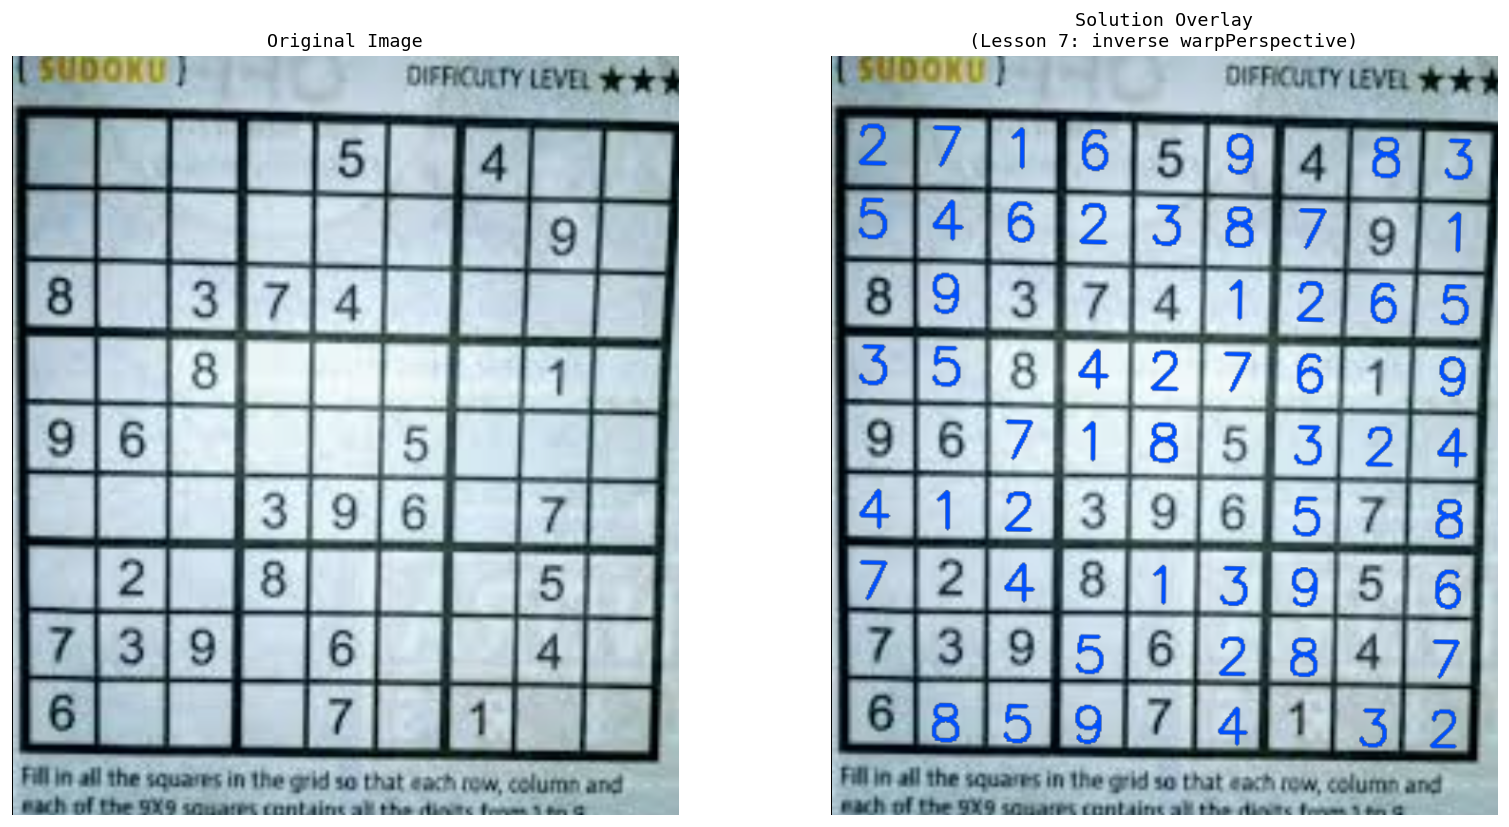

 Step 8 complete — result saved to: /Users/alex_brut/Desktop/Ai-Vision-Course/Sudoku Solver Project/data/solved_results/solved_result.png


In [14]:
# ============================================================
# CELL 23 — Step 8: Overlay Solution on Original Image
# ============================================================

def draw_solution_on_grid(board_recognised, board_solved,
                          grid_size=450, cell_size=50):
    """
    Draw only the newly solved digits (not the original given digits)
    onto a transparent canvas the same size as the warped grid.
    Returns BGRA image (A channel = 0 where no digit drawn).
    """
    canvas = np.zeros((grid_size, grid_size, 4), dtype=np.uint8)

    for r in range(9):
        for c in range(9):
            orig_val   = board_recognised[r][c] if isinstance(board_recognised, list) \
                         else int(board_recognised[r, c])
            solved_val = board_solved[r][c] if isinstance(board_solved, list) \
                         else int(board_solved[r, c])

            # Only draw cells that were empty (now filled by solver)
            if orig_val != 0:
                continue

            text  = str(solved_val)
            font  = cv2.FONT_HERSHEY_SIMPLEX
            scale = 1.2
            thick = 2
            (tw, th), _ = cv2.getTextSize(text, font, scale, thick)

            x0 = c * cell_size + (cell_size - tw) // 2
            y0 = r * cell_size + (cell_size + th) // 2

            # Draw in blue (BGR) with full alpha
            cv2.putText(canvas, text, (x0, y0),
                        font, scale, (255, 80, 0, 255), thick)

    return canvas


def overlay_solution(original_img, board_orig, board_solved,
                     H_inv, grid_size=450, cell_size=50):
    """
    Lesson 7: inverse warpPerspective to project solution back.
    1. Draw digits on grid canvas
    2. Warp canvas using H_inv to original perspective
    3. Alpha-blend with original
    """
    h_orig, w_orig = original_img.shape[:2]

    # Draw digits on rectified canvas
    canvas_bgra = draw_solution_on_grid(
        board_orig, board_solved, grid_size, cell_size
    )

    # Separate colour and alpha channels
    canvas_bgr   = canvas_bgra[:, :, :3]
    canvas_alpha = canvas_bgra[:, :,  3]

    # Warp colour back to original perspective (Lesson 7: inverse homography)
    warped_back = cv2.warpPerspective(
        canvas_bgr, H_inv, (w_orig, h_orig)
    )
    alpha_back  = cv2.warpPerspective(
        canvas_alpha, H_inv, (w_orig, h_orig)
    )

    # Alpha blend: result = original*(1-a) + overlay*a
    alpha_f = (alpha_back.astype('float32') / 255.0)[..., np.newaxis]
    result  = (original_img.astype('float32') * (1 - alpha_f)
               + warped_back.astype('float32') * alpha_f)
    result  = np.clip(result, 0, 255).astype(np.uint8)

    return result


if GRID_DETECTED and SOLVER_SUCCESS:
    result_img = overlay_solution(
        original, board_list, solved_board, H_inv, GRID_SIZE, CELL_SIZE
    )

    # Side-by-side comparison
    show_images(
        [original, result_img],
        titles=['Original Image', 'Solution Overlay\n(Lesson 7: inverse warpPerspective)'],
        figsize=(14, 7)
    )

    # Save result
    out_path = str(RESULTS_DIR / 'solved_result.png')
    cv2.imwrite(out_path, result_img)
    print(f' Step 8 complete — result saved to: {out_path}')
elif not SOLVER_SUCCESS:
    print('  Solver did not find a valid solution — overlay skipped.')
    result_img = original.copy()
else:
    print('  Grid not detected — overlay skipped.')
    result_img = original.copy()

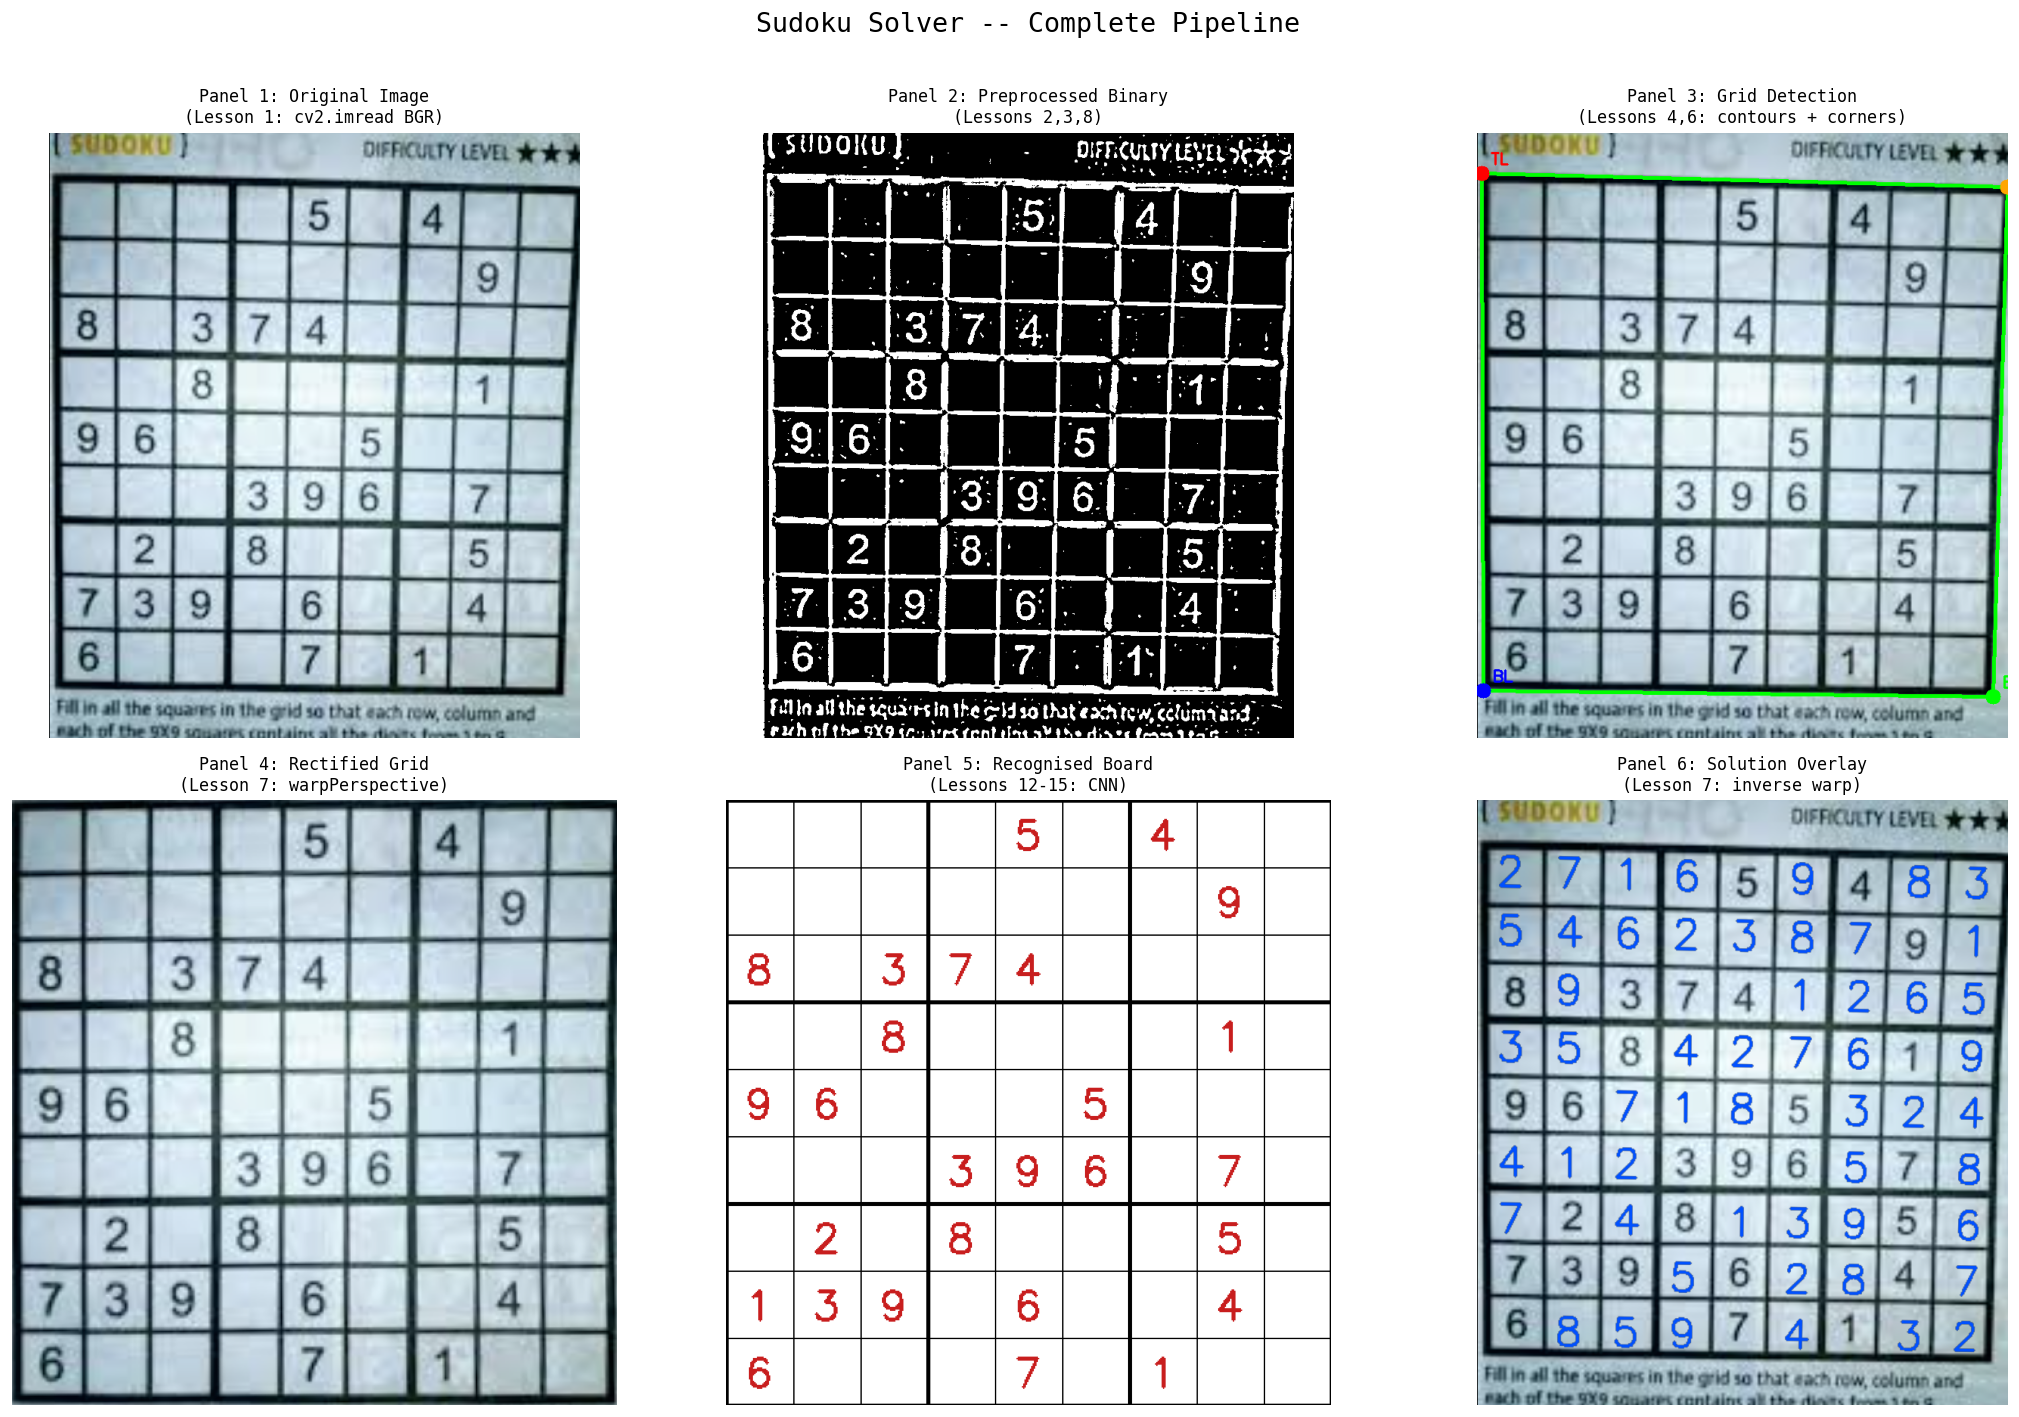

6-panel figure saved.


In [15]:
# ============================================================
# CELL 23 -- Full Pipeline Visualisation (6-Panel Figure)
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Sudoku Solver -- Complete Pipeline', fontsize=16, y=0.98)

panels = [
    (original,        'Panel 1: Original Image\n(Lesson 1: cv2.imread BGR)',      None),
    (thresh,          'Panel 2: Preprocessed Binary\n(Lessons 2,3,8)',             'gray'),
    (debug_img if GRID_DETECTED else original,
                      'Panel 3: Grid Detection\n(Lessons 4,6: contours + corners)', None),
    (warped_color if GRID_DETECTED else original,
                      'Panel 4: Rectified Grid\n(Lesson 7: warpPerspective)',      None),
    (None,            'Panel 5: Recognised Board\n(Lessons 12-15: CNN)',           None),
    (result_img,      'Panel 6: Solution Overlay\n(Lesson 7: inverse warp)',       None),
]

axes = [fig.add_subplot(2, 3, i + 1) for i in range(6)]

for ax, (img, title, cmap) in zip(axes, panels):
    ax.set_title(title, fontsize=10)
    if img is None:
        if GRID_DETECTED:
            board_canvas = np.ones((450, 450, 3), dtype=np.uint8) * 255
            font = cv2.FONT_HERSHEY_SIMPLEX
            for r in range(9):
                for c in range(9):
                    v = int(board[r, c])
                    if v != 0:
                        cv2.putText(board_canvas, str(v),
                                    (c * 50 + 14, r * 50 + 36),
                                    font, 1.0, (30, 30, 200), 2)
            for i in range(10):
                t = 2 if i % 3 == 0 else 1
                cv2.line(board_canvas, (i*50, 0),   (i*50, 450),   (0,0,0), t)
                cv2.line(board_canvas, (0, i*50),   (450, i*50),   (0,0,0), t)
            ax.imshow(cv2.cvtColor(board_canvas, cv2.COLOR_BGR2RGB))
        else:
            ax.text(0.5, 0.5, 'Grid not detected',
                    ha='center', va='center', transform=ax.transAxes)
    else:
        disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
        ax.imshow(disp, cmap=cmap)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(str(RESULTS_DIR / 'pipeline_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('6-panel figure saved.')


In [16]:
# ============================================================
# CELL 25 — Final Stats Summary
# ============================================================

img_name = Path(IMAGE_PATH).name

print('=' * 60)
print('  FINAL PROJECT — SUDOKU SOLVER RESULTS')
print('=' * 60)
print(f'  Image              : {img_name}')
print(f'  Image shape        : {original.shape}')
print(f'  Grid Detection     : {"SUCCESS" if GRID_DETECTED else "FAILED"}')

if GRID_DETECTED:
    print(f'  Cells extracted    : {9*9}')
    print(f'  Empty cells found  : {int(empty_map.sum())}')
    print(f'  Filled cells       : {int((~empty_map).sum())}')
    print(f'  CNN Test Accuracy  : {CNN_TEST_ACC*100:.2f}%')
    if KNOWN_PUZZLE is not None:
        known      = np.array(KNOWN_PUZZLE)
        filled_m   = known != 0
        n_correct  = int(((board == known) & filled_m).sum())
        n_filled   = int(filled_m.sum())
        print(f'  CNN Digit Accuracy : {n_correct}/{n_filled} = {n_correct/n_filled*100:.1f}%')
    print(f'  Solver             : {"SUCCESS" if SOLVER_SUCCESS else "FAILED"}')
    print(f'  Solution Valid     : {SOLVER_SUCCESS}')

print('=' * 60)

print('\nLesson Coverage:')
lessons_used = {
    'Lesson 1'    : 'cv2.imread, BGR→RGB conversion',
    'Lesson 2'    : 'CLAHE colour balancing',
    'Lesson 3'    : 'Gaussian blur + Unsharp Masking',
    'Lesson 4'    : 'Edge detection / contour finding',
    'Lesson 5'    : 'Binary thresholding concept',
    'Lesson 6'    : 'Corner detection + ordering',
    'Lesson 7'    : 'Homography + warpPerspective (fwd + inv)',
    'Lesson 8'    : 'Otsu / Adaptive threshold + variance',
    'Lesson 9'    : 'ROI concept (cells as bounding boxes)',
    'Lesson 10'   : 'Cell tracking through pipeline',
    'Lessons 12–15': 'CNN + BatchNorm + Dropout + data augment',
}
for lesson, desc in lessons_used.items():
    print(f'  {lesson:<15} {desc}')

  FINAL PROJECT — SUDOKU SOLVER RESULTS
  Image              : test1.png
  Image shape        : (800, 702, 3)
  Grid Detection     : SUCCESS
  Cells extracted    : 81
  Empty cells found  : 54
  Filled cells       : 27
  CNN Test Accuracy  : 99.63%
  Solver             : SUCCESS
  Solution Valid     : True

Lesson Coverage:
  Lesson 1        cv2.imread, BGR→RGB conversion
  Lesson 2        CLAHE colour balancing
  Lesson 3        Gaussian blur + Unsharp Masking
  Lesson 4        Edge detection / contour finding
  Lesson 5        Binary thresholding concept
  Lesson 6        Corner detection + ordering
  Lesson 7        Homography + warpPerspective (fwd + inv)
  Lesson 8        Otsu / Adaptive threshold + variance
  Lesson 9        ROI concept (cells as bounding boxes)
  Lesson 10       Cell tracking through pipeline
  Lessons 12–15   CNN + BatchNorm + Dropout + data augment


---
## Conclusion

This project demonstrates a complete computer vision pipeline that solves Sudoku puzzles from photographs.  Every major module was informed by a specific lesson from the course:

| Lesson | Technique | Where Used |
|--------|-----------|------------|
| 1 | OpenCV basics, BGR→RGB | Image loading |
| 2 | Colour balancing (CLAHE) | Preprocessing & cell normalisation |
| 3 | Gaussian blur, Unsharp Masking | Denoising & cell sharpening |
| 4 | Hough / Edge detection | Grid contour detection |
| 5 | Dithering / quantisation | Binary thresholding concept |
| 6 | Harris corners / descriptors | Corner ordering (TL→TR→BR→BL) |
| 7 | Homography, `warpPerspective` | Grid rectification **and** inverse overlay |
| 8 | Otsu / Adaptive threshold | Cell binarisation + variance empty-detection |
| 9 | ROI detection | Cells as regions of interest |
| 10 | Object tracking | Tracking 81 cells through the pipeline |
| 12–15 | CNN, BatchNorm, Dropout, overfitting | Digit recognition model |

### Key Engineering Decisions

- **Combined dataset** (MNIST + synthetic printed digits) solved the font-mismatch problem that caused pure MNIST models to fail on printed sudoku digits.
- **Connected Components** for digit localisation eliminated the brittle fixed-border-crop approach, handling any digit position within a cell.
- **Automatic background detection** (mean brightness threshold) makes the pipeline robust to both light and dark sudoku photos.
- **Saved model** (`.keras`) means re-running the notebook after training takes only seconds.

